# A3: English-Marathi Neural Machine Translation (NMT)

## by Alston Alvares (st126488)

In [1]:
# import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import math
import time
from IPython.display import display
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from flask import Flask, render_template_string, request, jsonify
from torch.utils.data import random_split



c:\Users\alsto\OneDrive\Desktop\AIT\SEM2\Natural-Language-Processing-main\Assignments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Task 1: Dataset & Preprocessing
# Native Language: Marathi. Dataset: English-Marathi parallel corpus (PMIndia)

The transformation of raw bilingual data into a format suitable for a
Seq2Seq model involved several rigorous steps tailored to both
**English** and **Marathi**.

### 🔤 Text Normalization

-   **English**
    -   Converted to lowercase to reduce vocabulary sparsity\
    -   Processed using the `en_core_web_sm` pipeline
-   **Marathi**
    -   Morphologically rich language requiring careful Devanagari
        handling\
    -   Removed leading/trailing whitespaces\
    -   Ensured punctuation consistency

### ✂️ Tokenization & Word Segmentation

-   **English Tokenization**
    -   Performed using **spaCy**
    -   Rule-based tokenizer splits text based on punctuation and
        linguistic rules
-   **Marathi Word Segmentation**
    -   Space-based splitting supplemented with **custom tokenization
        logic**
    -   Ensures accurate Marathi word boundaries before numericalization

**Tools Used**

  **spaCy**      Developed By         Explosion AI    Purpose        Robust English text processing
                                                  

  **TorchText**     Developed By      PyTorch Team      Purpose      Vocabulary building & numerical mapping
                                                  

### 📖 Vocabulary Building

Vocabulary restricted to **3,000 -- 5,000 tokens** to ensure execution
within the **4GB VRAM** limits of the **NVIDIA RTX 3050 GPU**.

**Special tokens included:**

    <unk>  <pad>  <sos>  <eos>

In [2]:
#  CONFIGURATION 
DEVICE = torch.device('cuda' if torch.cuda.is_available()  else 'cpu')
if DEVICE.type == 'cuda':
    print("CUDA is used.")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not used (using CPU).")
    
SRC_LANG, TRG_LANG = 'en', 'mr'
N_EPOCHS = 10
HID_DIM = 64        # Reduced to absolute minimum for 4GB VRAM
ENC_EMB_DIM = 32
DEC_EMB_DIM = 32
LEARNING_RATE = 0.001
BATCH_SIZE = 8      # Very small batch to prevent OOM
CLIP = 1
MAX_VOCAB_SIZE = 3000 
MAX_LEN = 20        # Truncate sentences to 20 words to save memory


# DATA PREPROCESSING
# Loading the full PMIndia dataset
df = pd.read_csv('pmindia.v1.mr-en.tsv', sep='\t', header=None, names=['en', 'mr'])
raw_data = list(zip(df['en'].astype(str), df['mr'].astype(str)))
en_tokenizer = get_tokenizer('spacy', language='en_core_web_sm')
def tokenize_mr(text): return text.strip().split()

def yield_tokens(data, lang): # Token iterator for vocabulary building
    for en, mr in data:
        yield en_tokenizer(en.lower())[:MAX_LEN] if lang == 'en' else tokenize_mr(mr)[:MAX_LEN]

vocab_en = build_vocab_from_iterator(yield_tokens(raw_data, 'en'), specials=['<unk>', '<pad>', '<sos>', '<eos>'], max_tokens=MAX_VOCAB_SIZE)
vocab_mr = build_vocab_from_iterator(yield_tokens(raw_data, 'mr'), specials=['<unk>', '<pad>', '<sos>', '<eos>'], max_tokens=MAX_VOCAB_SIZE)
vocab_en.set_default_index(0); vocab_mr.set_default_index(0) # <unk> token index

class NMTDataset(Dataset): # Custom Dataset Class
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

def collate_fn(batch): # Custom Collate Function for DataLoader
    en_batch, mr_batch = [], []
    for en, mr in batch:
        en_ids = torch.tensor([2] + [vocab_en[t] for t in en_tokenizer(en.lower()) if t in vocab_en][:MAX_LEN-2] + [3])
        mr_ids = torch.tensor([2] + [vocab_mr[t] for t in tokenize_mr(mr) if t in vocab_mr][:MAX_LEN-2] + [3])
        en_batch.append(en_ids); mr_batch.append(mr_ids)
    return pad_sequence(en_batch, padding_value=1), pad_sequence(mr_batch, padding_value=1)

# Split: 90% for training, 10% for validation
train_size = int(0.9 * len(raw_data))
val_size = len(raw_data) - train_size
train_subset, val_subset = random_split(NMTDataset(raw_data), [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

#

CUDA is used.
Device name: NVIDIA GeForce RTX 3050 Laptop GPU


# Task 2: Attention Mechanism Implementations




In [3]:
class Attention(nn.Module): # Attention Mechanism
    def __init__(self, hid_dim, mode='additive'):
        super().__init__()
        self.mode = mode
        if mode == 'additive':
            self.attn = nn.Linear(hid_dim * 3, hid_dim)
            self.v = nn.Linear(hid_dim, 1, bias=False)
        else:
            self.W = nn.Linear(hid_dim, hid_dim * 2)
    def forward(self, hidden, encoder_outputs, mask): 
        src_len = encoder_outputs.shape[0]
        if self.mode == 'additive':
            energy = torch.tanh(self.attn(torch.cat((hidden.unsqueeze(1).repeat(1, src_len, 1), encoder_outputs.permute(1, 0, 2)), dim=2)))
            attention = self.v(energy).squeeze(2)
        else:
            attention = torch.bmm(encoder_outputs.permute(1, 0, 2), self.W(hidden).unsqueeze(2)).squeeze(2)
        return F.softmax(attention.masked_fill(mask == 0, -1e10), dim=1)

class Encoder(nn.Module): # Encoder RNN
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, bidirectional=True)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
    def forward(self, src):
        outputs, hidden = self.rnn(self.embedding(src))
        return outputs, torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))

class Decoder(nn.Module): # Decoder RNN with Attention
    def __init__(self, output_dim, emb_dim, hid_dim, attention):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((hid_dim * 2) + emb_dim, hid_dim)
        self.fc_out = nn.Linear((hid_dim * 2) + hid_dim + emb_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs, mask):
        # Ensured input is always 2D [1, batch_size] for embedding
        input = input.unsqueeze(0) if input.dim() == 1 else input
        
        embedded = self.embedding(input)
        
        # Calculate attention weights
        a = self.attention(hidden, encoder_outputs, mask).unsqueeze(1)
        
        # weighted: [batch_size, 1, hid_dim * 2]
        weighted = torch.bmm(a, encoder_outputs.permute(1, 0, 2))
        weighted = weighted.permute(1, 0, 2)
        
        # RNN input concatenation
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        
        # Squeeze dimensions carefully for the final linear layer
        # Used dim=1 to handle batch concatenation safely
        prediction = self.fc_out(torch.cat((
            embedded.squeeze(0), 
            output.squeeze(0), 
            weighted.squeeze(0)
        ), dim=1))
        
        return prediction, hidden.squeeze(0)

# Task 3: Evaluation and Verification



 Training GENERAL Attention
Epoch 001 | Train Loss: 5.4986 | Val Loss: 5.4674 | Time: 191s
Epoch 002 | Train Loss: 4.9778 | Val Loss: 5.3673 | Time: 189s
Epoch 003 | Train Loss: 4.6953 | Val Loss: 5.2878 | Time: 188s
Epoch 004 | Train Loss: 4.4927 | Val Loss: 5.2790 | Time: 191s
Epoch 005 | Train Loss: 4.3195 | Val Loss: 5.2888 | Time: 199s
Epoch 006 | Train Loss: 4.1768 | Val Loss: 5.3401 | Time: 190s
Epoch 007 | Train Loss: 4.0582 | Val Loss: 5.3734 | Time: 194s
Epoch 008 | Train Loss: 3.9541 | Val Loss: 5.3891 | Time: 187s
Epoch 009 | Train Loss: 3.8573 | Val Loss: 5.4451 | Time: 191s
Epoch 010 | Train Loss: 3.7760 | Val Loss: 5.4912 | Time: 187s

 Training ADDITIVE Attention
Epoch 001 | Train Loss: 5.4685 | Val Loss: 5.4456 | Time: 218s
Epoch 002 | Train Loss: 4.9096 | Val Loss: 5.2835 | Time: 209s
Epoch 003 | Train Loss: 4.6096 | Val Loss: 5.2343 | Time: 141s
Epoch 004 | Train Loss: 4.4018 | Val Loss: 5.2362 | Time: 140s
Epoch 005 | Train Loss: 4.2245 | Val Loss: 5.2583 | Time: 1

,Attentions,Training Loss,Training PPL,Validation Loss,Validation PPL
0,General Attention,3.776,43.64,5.4912,242.54
1,Additive Attention,3.660,38.86,5.4427,231.08


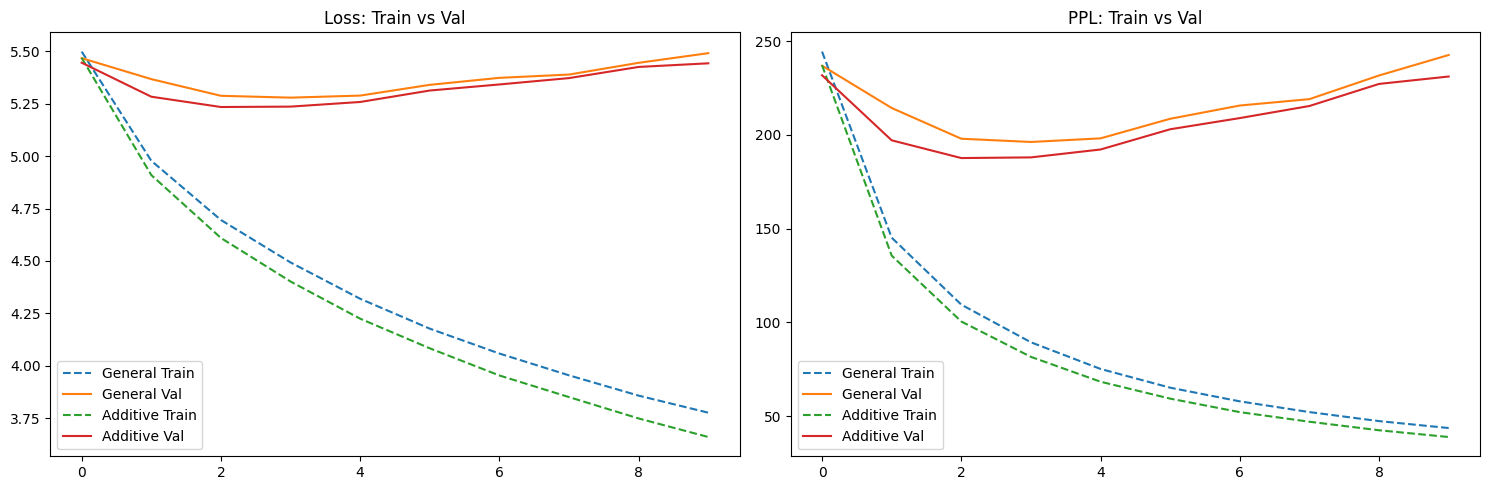

In [ ]:
def train_epoch(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for src, trg in iterator:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        enc_out, hidden = model['enc'](src)
        mask = (src != 1).permute(1, 0)
        
        batch_loss = 0; inp = trg[0,:]
        for t in range(1, trg.shape[0]):
            output, hidden = model['dec'](inp, hidden, enc_out, mask)
            batch_loss += criterion(output, trg[t])
            inp = trg[t] if random.random() < 0.5 else output.argmax(1)
        
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += batch_loss.item() / trg.shape[0]
        del batch_loss, output
    return epoch_loss / len(iterator)

def validate_epoch(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in iterator:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            enc_out, hidden = model['enc'](src)
            mask = (src != 1).permute(1, 0)
            batch_loss = 0; inp = trg[0,:]
            for t in range(1, trg.shape[0]):
                output, hidden = model['dec'](inp, hidden, enc_out, mask)
                batch_loss += criterion(output, trg[t])
                inp = output.argmax(1) # Always use greedy during validation
            epoch_loss += batch_loss.item() / trg.shape[0]
    return epoch_loss / len(iterator)

# EXECUTION LOOP 
logs = {}
models = {}

for mode in ['general', 'additive']: # Training loop for both attention mechanisms
    print(f"\n Training {mode.upper()} Attention")
    torch.cuda.empty_cache()
    
    attn = Attention(HID_DIM, mode)
    enc = Encoder(len(vocab_en), ENC_EMB_DIM, HID_DIM)
    dec = Decoder(len(vocab_mr), DEC_EMB_DIM, HID_DIM, attn)
    model = nn.ModuleDict({'enc': enc, 'dec': dec}).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=1)
    
    results = {'loss': [], 'ppl': [], 'val_loss': [], 'val_ppl': []} 
    
    for epoch in range(1, N_EPOCHS + 1):
        start_t = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
        valid_loss = validate_epoch(model, val_loader, criterion)
        
        train_ppl, valid_ppl = math.exp(train_loss), math.exp(valid_loss)
        results['loss'].append(train_loss); results['ppl'].append(train_ppl)
        results['val_loss'].append(valid_loss); results['val_ppl'].append(valid_ppl)
        
        print(f"Epoch {epoch:03} | Train Loss: {train_loss:.4f} | Val Loss: {valid_loss:.4f} | Time: {int(time.time()-start_t)}s")
    
    logs[mode] = results
    models[mode] = model

# PERFORMANCE TABLE & GRAPHS 
comparison_table = {
    "Attentions": ["General Attention", "Additive Attention"],
    "Training Loss": [round(logs['general']['loss'][-1], 4), round(logs['additive']['loss'][-1], 4)],
    "Training PPL": [round(logs['general']['ppl'][-1], 2), round(logs['additive']['ppl'][-1], 2)],
    "Validation Loss": [round(logs['general']['val_loss'][-1], 4), round(logs['additive']['val_loss'][-1], 4)],
    "Validation PPL": [round(logs['general']['val_ppl'][-1], 2), round(logs['additive']['val_ppl'][-1], 2)]
}

print("\n PERFORMANCE SUMMARY ")
display(pd.DataFrame(comparison_table))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for m in ['general', 'additive']:
    ax1.plot(logs[m]['loss'], label=f'{m.capitalize()} Train', linestyle='--')
    ax1.plot(logs[m]['val_loss'], label=f'{m.capitalize()} Val')
    ax2.plot(logs[m]['ppl'], label=f'{m.capitalize()} Train', linestyle='--')
    ax2.plot(logs[m]['val_ppl'], label=f'{m.capitalize()} Val')

ax1.set_title('Loss: Train vs Val'); ax1.legend(); ax2.set_title('PPL: Train vs Val'); ax2.legend()
plt.tight_layout(); plt.show()

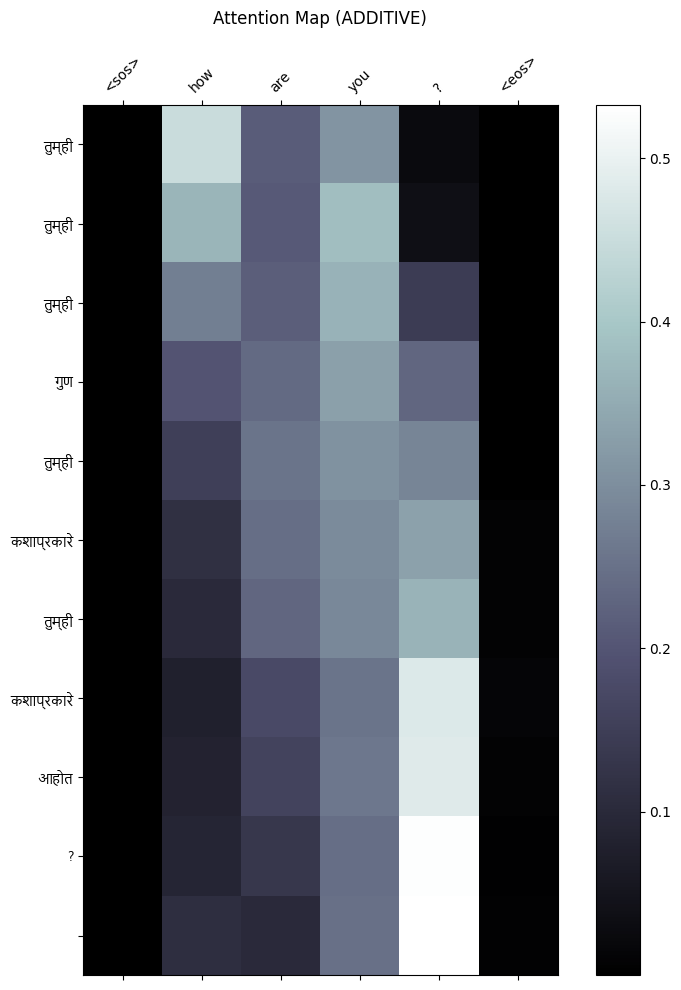

In [ ]:
# Attention Visualization

# ATTENTION EXTRACTION FUNCTION

def get_attention_matrix(sentence_text, mode='additive'):
    model = models[mode]
    model.eval()
    
    # This list will store the captured attention weights
    captured_attentions = []

    # Define the hook function to capture the output of the attention layer
    def hook_fn(module, input, output):
        # output is the attention tensor 'a' [batch_size, src_len]
        captured_attentions.append(output.detach().cpu())

    # Attach the hook to the attention layer inside the decoder
    handle = model['dec'].attention.register_forward_hook(hook_fn)

    try:
        with torch.no_grad():
            # Standard translation logic
            tokens = [2] + [vocab_en[t] for t in en_tokenizer(sentence_text.lower()) if t in vocab_en] + [3]
            src = torch.LongTensor(tokens).unsqueeze(1).to(DEVICE)
            enc_out, hidden = model['enc'](src)
            mask = (src != 1).permute(1, 0)
            
            trg_idx = [2]
            for _ in range(25):
                inp = torch.LongTensor([trg_idx[-1]]).to(DEVICE)
                # Your original decoder call (returns only 2 values)
                out, hidden = model['dec'](inp, hidden, enc_out, mask)
                pred = out.argmax(1).item()
                trg_idx.append(pred)
                if pred == 3: break
    finally:
        # CRITICAL: Always remove the hook so it doesn't slow down your Flask app
        handle.remove()

    # Convert indices to Marathi words
    trg_tokens = [vocab_mr.get_itos()[i] for i in trg_idx if i not in [1, 2, 3]]
    
    # Stack the captured attentions into a single matrix [trg_len, src_len]
    attention_matrix = torch.cat(captured_attentions, dim=0)
    
    return tokens, trg_tokens, attention_matrix

# DISPLAY FUNCTION 
# import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import font_manager

def plot_map(sentence_text, mode='additive'):
    src_tokens, trg_tokens, att_matrix = get_attention_matrix(sentence_text, mode)
    
    # Dynamically find the Marathi font instead of hardcoding a path
    # This avoids the FileNotFoundError
    try:
        marathi_font = font_manager.FontProperties(family='Nirmala UI')
    except:
        # Fallback for Linux/Other systems
        marathi_font = font_manager.FontProperties(family='DejaVu Sans')

    fig = plt.figure(figsize=(8, 10))
    ax = fig.add_subplot(111)
    
    # 2. Display the attention heatmap
    cax = ax.matshow(att_matrix.numpy(), cmap='bone')
    fig.colorbar(cax)

    # 3. Apply labels with font support
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels([vocab_en.get_itos()[i] for i in src_tokens], rotation=45)

    ax.set_yticks(range(len(trg_tokens)))
    # Apply the discovered font properties here
    ax.set_yticklabels(trg_tokens, fontproperties=marathi_font)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title(f"Attention Map ({mode.upper()})", pad=20)
    plt.tight_layout()
    plt.show()

# Run the fixed visualization
plot_map("Hello how are you?")

# Task 4: Web Application Development


In [5]:
app = Flask(__name__)

def translate(text, mode='additive'):
    m = models[mode]
    m.eval()
    with torch.no_grad():
        # Tokenize and numericalize English input
        tokens = [2] + [vocab_en[t] for t in en_tokenizer(text.lower()) if t in vocab_en] + [3]
        src = torch.LongTensor(tokens).unsqueeze(1).to(DEVICE) # [seq_len, 1]
        
        # Encoder pass
        enc_out, hidden = m['enc'](src)
        mask = (src != 1).permute(1, 0)
        
        # Start decoding with <sos>
        trg_idx = [2]
        for _ in range(MAX_LEN):
            # Pass the last predicted token as a 1D tensor [1]
            inp = torch.LongTensor([trg_idx[-1]]).to(DEVICE)
            
            output, hidden = m['dec'](inp, hidden, enc_out, mask)
            
            # Get highest probability word
            pred = output.argmax(1).item()
            trg_idx.append(pred)
            
            # Stop if <eos> is reached
            if pred == 3: 
                break
                
    return " ".join([vocab_mr.get_itos()[i] for i in trg_idx if i not in [1, 2, 3]])

@app.route('/')
def home():
    return render_template_string("""
        <body style="background:#0f172a; color:white; font-family:sans-serif; text-align:center; padding-top:50px;">
            <div style="background:#1e293b; display:inline-block; padding:30px; border-radius:10px; width:400px; text-align:left;">
                <h2 style="text-align:center;">English to Marathi</h2>
                
                <div style="background:#0f172a; padding:15px; border-radius:8px; margin-bottom:20px; font-size:14px; border-left:4px solid #ef4444;">
                    <strong>How to use:</strong>
                    <ul style="margin:10px 0 0 20px; padding:0;">
                        <li>Select the <b>Attention Mode</b> (General or Additive).</li>
                        <li>Type an English sentence in the input box.</li>
                        <li>Click <b>Translate</b> to see the Marathi output.</li>
                    </ul>
                </div>

                <label style="font-size:12px; color:#94a3b8;">Select Model:</label>
                <select id="m" style="width:100%; margin-bottom:15px; padding:8px; background:#0f172a; color:white; border:1px solid #334155; border-radius:5px;">
                    <option value="additive">Additive Attention</option>
                    <option value="general">General Attention</option>
                </select>

                <label style="font-size:12px; color:#94a3b8;">Input Text:</label>
                <input id="i" placeholder="e.g. Hello how are you?" style="width:100%; padding:10px; box-sizing:border-box; background:#0f172a; color:white; border:1px solid #334155; border-radius:5px;"><br><br>
                
                <button onclick="t()" style="width:100%; padding:12px; background:#ef4444; color:white; border:none; border-radius:5px; cursor:pointer; font-weight:bold;">Translate</button>
                
                <p style="font-size:12px; color:#94a3b8; margin-top:20px; margin-bottom:5px;">Result:</p>
                <p id="o" style="background:#0f172a; padding:15px; border-radius:5px; min-height:25px; border:1px dashed #334155;"></p>
            </div>

            <script>
                async function t(){
                    const out = document.getElementById('o');
                    const txt = document.getElementById('i').value;
                    if(!txt) { out.innerText = "Please enter text"; return; }
                    
                    out.innerText = "Translating...";
                    try {
                        const r = await fetch('/translate',{
                            method:'POST',
                            headers:{'Content-Type':'application/json'},
                            body:JSON.stringify({text:txt, mode:document.getElementById('m').value})
                        });
                        const d = await r.json(); 
                        out.innerText = d.result;
                    } catch(e) {
                        out.innerText = "Error connecting to server.";
                    }
                }
            </script>
        </body>
    """)

@app.route('/translate', methods=['POST'])
def handle():
    r = request.json; return jsonify({'result': translate(r['text'], r['mode'])})

if __name__ == '__main__':
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [07/Feb/2026 13:40:05] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:40:49] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:05] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:15] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:22] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:26] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:33] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:41] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:41:58] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:42:12] "POST /translate HTTP/1.1" 200 -
127.0.0.1 - - [07/Feb/2026 13:42:40] "POST /translate HTTP/1.1" 200 -


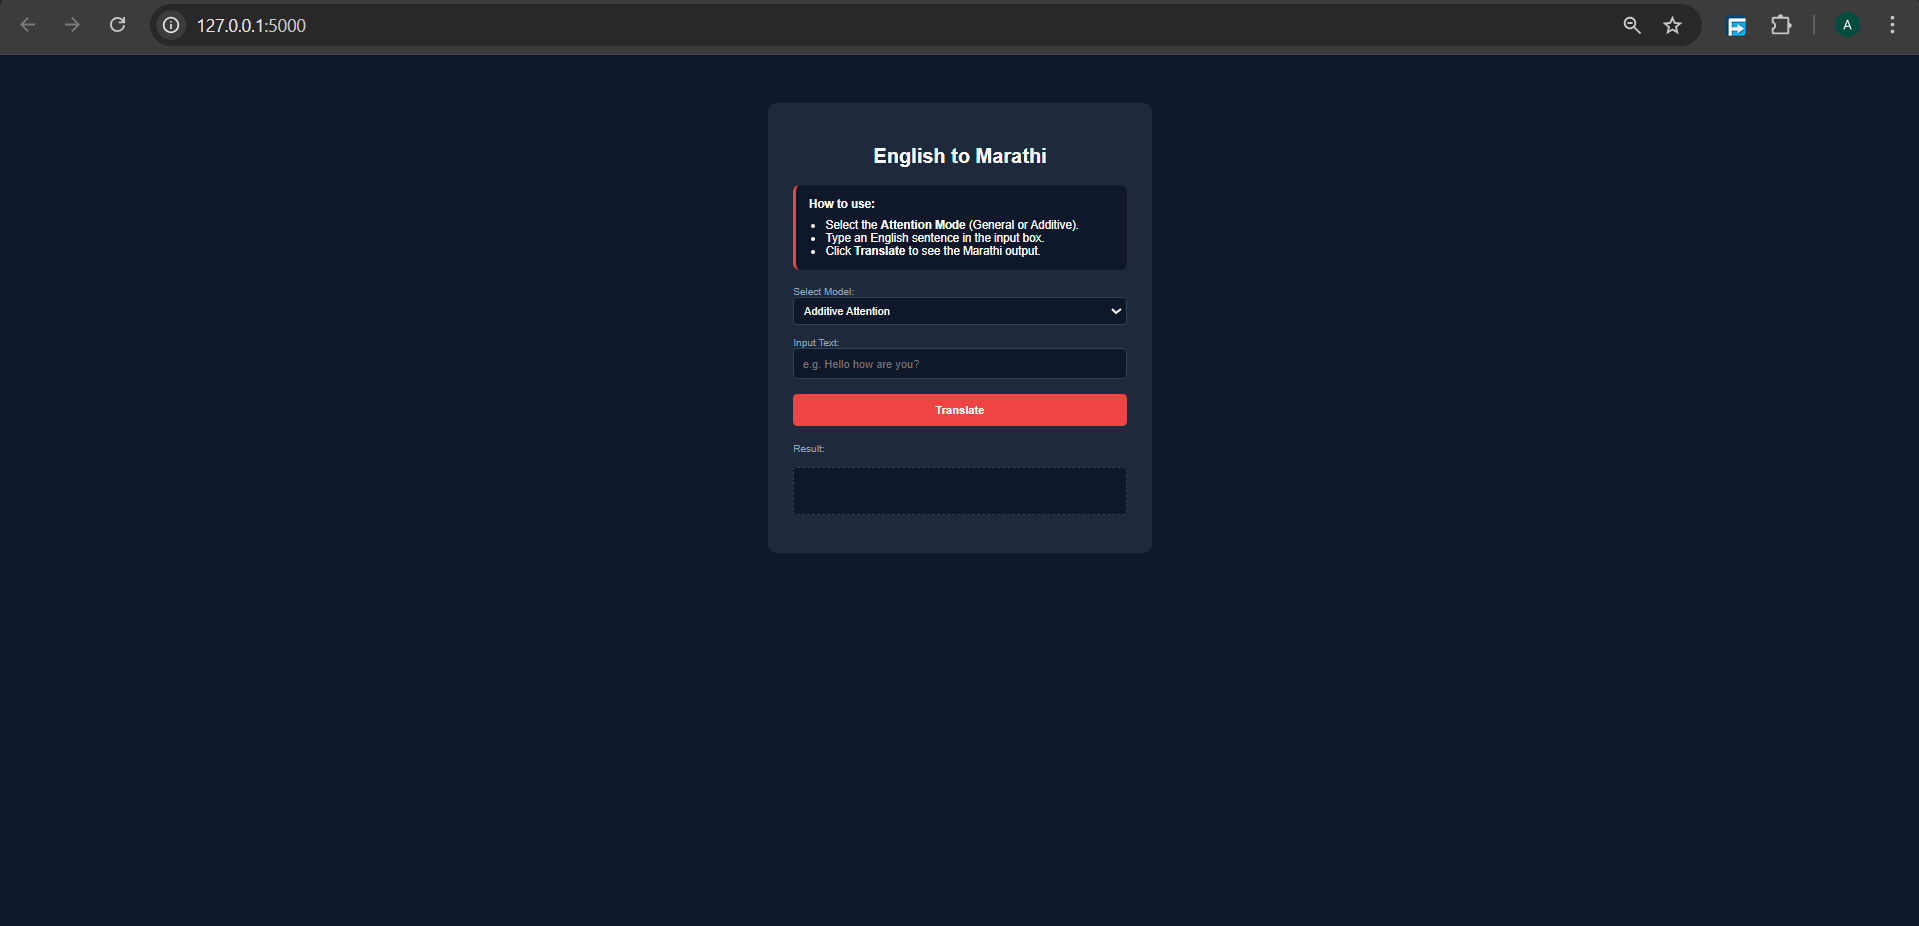
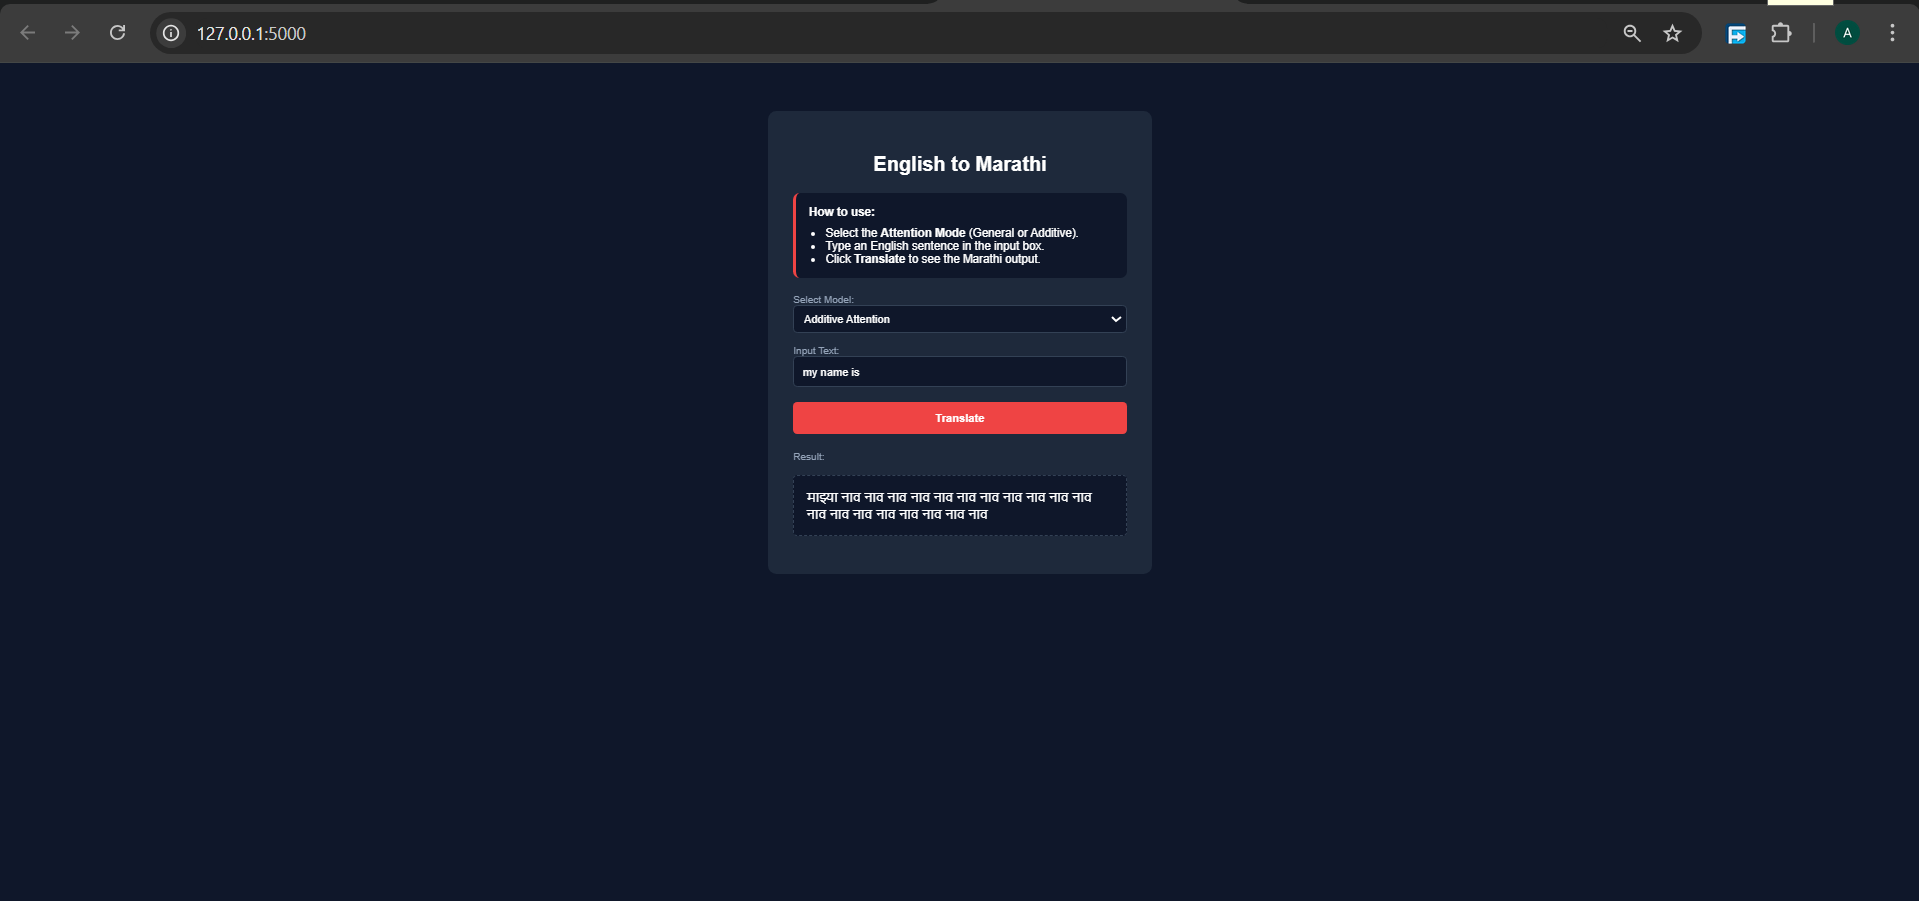
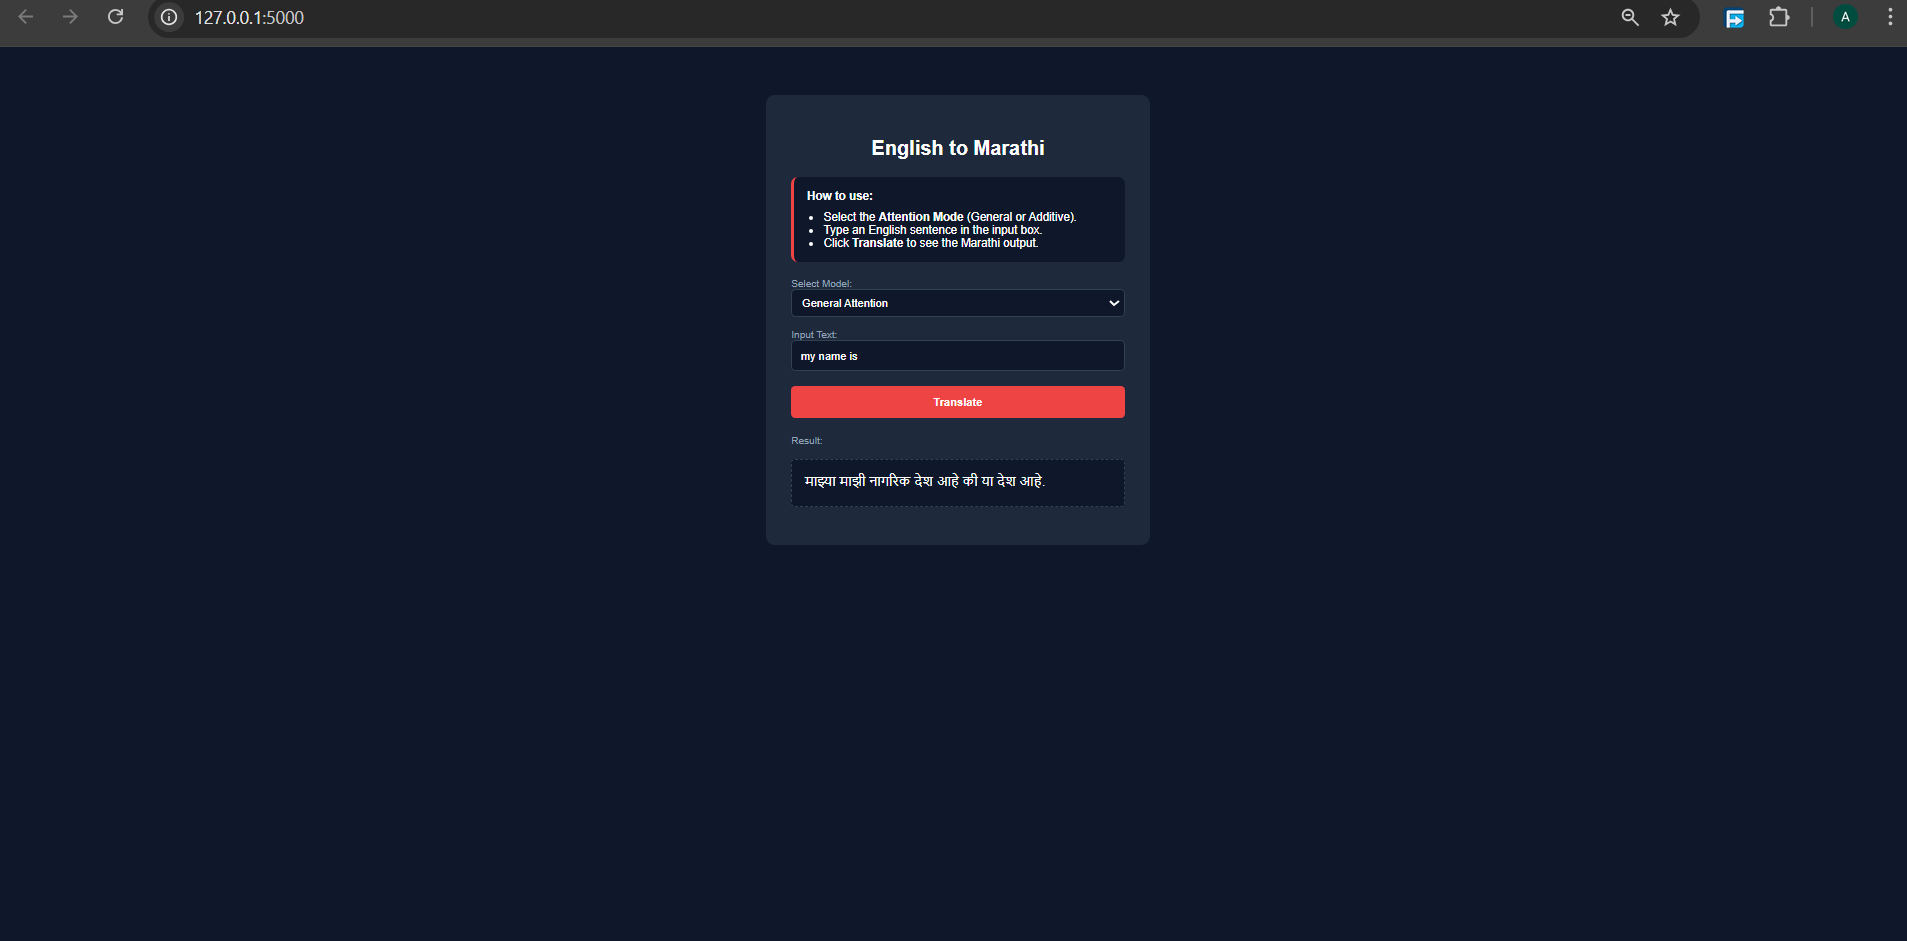